In [55]:
#Importacion de librerias requeridas

import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from google.cloud import bigquery
from datetime import timedelta
import plotly.graph_objects as go
from prophet.plot import plot_plotly
import matplotlib.pyplot as plt


In [56]:
# Configuracion

#Elegimos el nombre del proyecto en cloud
PROJECT_ID = "inventarioproject-471611"

#Elegimos el dataset a trabajar que esta dentro del proyecto que elegimos anteriormente
DATASET = "inventarioproject_henry"


#Elegimos la tabla destino (la creamos)
TABLE_FORECASTS = f"{PROJECT_ID}.{DATASET}.sales_forecasts"  

#Horizonte de prediccion
HORIZON_WEEKS = 8

In [57]:
# 1) Cargar datos (ej: desde BigQuery)
client = bigquery.Client(project=PROJECT_ID)
query = """
SELECT inventoryid, salesdate, salesquantity
FROM `inventarioproject-471611.inventarioproject_henry.sales_2017_clean`
WHERE inventoryid = '1_HARDERSFIELD_1004'  -- cambiar por el id
"""

#Leemos el csv
df = pd.read_csv(r"G:\Mi unidad\proyecto_inventario\clean\ventas_2017_clean.csv")

In [75]:
# 2) Preprocesar: agrego por semana (cambiar a 'D' para diario)

columna = 'salesdollars'

df['salesdate'] = pd.to_datetime(df['salesdate'], errors='coerce')

# Sumar ventas por día
df_prophet = df.groupby('salesdate').agg({
    columna: 'sum' 
}).reset_index()

# Renombrar columnas para Prophet
df_prophet = df_prophet.rename(columns={'salesdate': 'ds', columna: 'y'})

# Opcional: ordenar por fecha
df_prophet = df_prophet.sort_values('ds')


In [77]:
# Suponiendo que tu df se llama df_prophet
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])  # asegurar formato datetime

In [80]:
# 1️ Crear el modelo
m = Prophet(weekly_seasonality=True, yearly_seasonality=False, daily_seasonality=False) # Prophet modela automáticamente patrones semanales y anuales.

# 2️ Entrenar el modelo
m.fit(df_prophet) 

# 3️ Crear fechas futuras para predecir (ejemplo: 30 días)
future = m.make_future_dataframe(periods=30)

# 4️ Hacer la predicción
forecast = m.predict(future)

# 5️ Mostrar predicciones
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])


14:07:05 - cmdstanpy - INFO - Chain [1] start processing
14:07:05 - cmdstanpy - INFO - Chain [1] done processing


           ds          yhat    yhat_lower    yhat_upper
0  2016-01-01  1.456590e+06  9.838964e+05  1.941204e+06
1  2016-01-02  1.408987e+06  9.410756e+05  1.890209e+06
2  2016-01-03  1.004208e+06  5.528364e+05  1.482025e+06
3  2016-01-04  7.967167e+05  3.417187e+05  1.245133e+06
4  2016-01-05  7.852841e+05  3.319802e+05  1.248907e+06
..        ...           ...           ...           ...
85 2016-03-26 -1.314590e+05 -5.687765e+05  3.332072e+05
86 2016-03-27 -5.362439e+05 -9.875036e+05 -9.040707e+04
87 2016-03-28 -7.437420e+05 -1.228654e+06 -2.829704e+05
88 2016-03-29 -7.551809e+05 -1.207038e+06 -2.519615e+05
89 2016-03-30 -7.146848e+05 -1.137701e+06 -2.549300e+05

[90 rows x 4 columns]


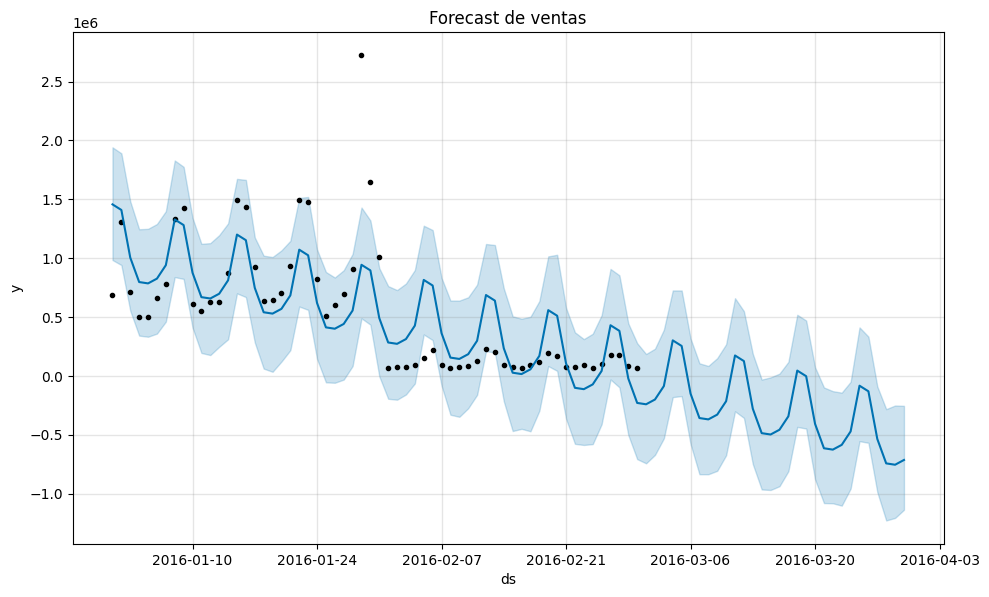

In [81]:
fig1 = m.plot(forecast)
plt.title("Forecast de ventas")
plt.show()

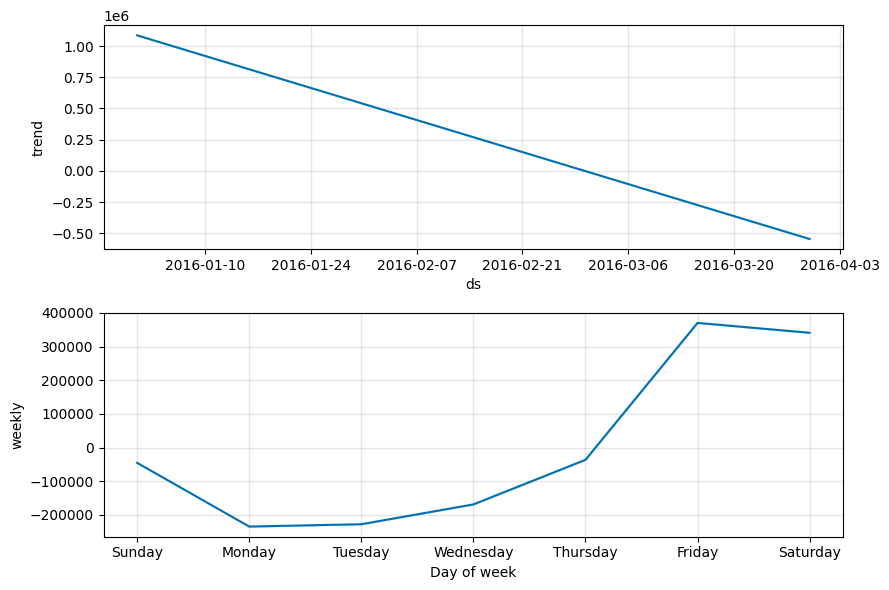

In [74]:
# Componentes (tendencia y estacionalidad)
fig2 = m.plot_components(forecast)
plt.show()

In [67]:
print(df['salesdate'].min(), df['salesdate'].max())


2016-01-01 00:00:00 2016-02-29 00:00:00
